# 【簡約版】GPT-2 推論エンジン入門

> 本記事は『GPT-2 推論エンジン入門』の簡約版です。各トピックの詳細な解説は本編をご参照ください。

https://zenn.dev/7shi/books/20260319-gpt2

# GPT-2 とは

GPT-2 は OpenAI が 2019 年に発表した言語モデルです。「テキストを受け取り、次のトークンを予測する」というシンプルな目的で訓練されています。

現代の LLM（GPT-4, Claude など）も Transformer アーキテクチャの基本はほぼ変わっておらず、GPT-2 との本質的な違いはパラメーター数と学習データの規模です。GPT-2 は現代の LLM の内部構造を理解するための最もコンパクトな出発点です。

なお、この記事で扱うのは**推論のみ**です。学習については対象外です。

また、Transformer には Encoder と Decoder の 2 つの部分があります。GPT-2 は Decoder のみで構成されたモデルで、この記事でも Decoder のみを説明します。Encoder と Decoder の違いは、Attention の節で簡単に触れます（詳細は本編の Attention の章を参照してください）。

# セットアップと実行

以下のリポジトリを使用します。

https://github.com/7shi/my-gpt2

```bash
git clone https://github.com/7shi/my-gpt2.git
cd my-gpt2
uv sync
make download
```

このノートブックをリポジトリの外に置いて使う場合は、ノートブックを動かす環境に、リポジトリを編集可能モードでインストールしてください。

```bash
pip install -e /path/to/my-gpt2
```

重みはインストール元のリポジトリの `weights` が参照されます。

## テキスト生成

GPT-2 は「次に来る単語を予測する」ことだけを学習した Base モデルです。質問に答えたり指示に従ったりする訓練（Instruction Tuning）は受けていないため、入力したテキスト（プロンプト）の続きを確率的に生成することしかできません。

GPT-2 は主に英語のテキストで学習されたモデルです。プロンプト（書き出し）を与えて、続きを生成させてみましょう。

In [ ]:
from my_gpt2.generate import generate

# 重みの置き場所（既定は my_gpt2 パッケージの1つ上の weights）。
# 編集可能インストールでない場合などは、my-gpt2 の weights ディレクトリを指定する
# my_gpt2.WEIGHTS_DIR = "/path/to/my-gpt2/weights"

_ = generate("The capital of France is")

The capital of France is Paris. Rodaining any part of Europe against a resurgent Italians, the former Belgian ruler, Napoleon II, who visited the Third Reich in September 1933, soon


英語ベースの GPT-2 はバイトレベル BPE により日本語の入力を受け付けますが、日本語として意味の通じる文章は生成できません。日本語を生成するには、日本語で学習された `rinna/japanese-gpt2-small` を `-m` オプションで指定します。モデル構造は GPT-2 と同一で、トークナイザーのみ SentencePiece に変更されています。

In [40]:
# -n 20 -m rinna/japanese-gpt2-small に相当
_ = generate("吾輩は猫で", n_tokens_to_generate=20, model_id="rinna/japanese-gpt2-small")

吾輩は猫であります、鍵が無いのです。吾輩は猫で有ります、鍵が有るので


生成は確率的なため、実行するたびに異なる結果が得られます。以下のオプションで生成の振る舞いを調整できます。

- **Temperature** (`-t`): 低い値ほど確信度の高い単語が選ばれやすく、高い値ほど多様な出力
- **Top-k** (`-k`): 確率上位 k 個のトークンのみを候補にする
- **Top-p** (`-p`): 累積確率が p に達するまでのトークンを候補にする

# 推論パイプラインの全体像

GPT-2 に入力されたテキストは以下のパイプラインを通り、「次に来る単語の確率分布」として出力されます。

1. テキスト
   - トークナイザー
     - BPE
     - SentencePiece
2. トークン ID 列
   - Embedding
3. ベクトル列
   - Transformer Block × 12
     - LayerNorm
     - Attention
     - 残差接続
     - LayerNorm
     - MLP
     - 残差接続
   - 最終 LayerNorm
   - LM Head
4. ロジット
   - サンプリング
5. 次のトークン

## モデルの重み

safetensors 形式（約 523 MB）で格納されています。768 は埋め込み次元、50257 は語彙数、1024 は最大トークン列長です。

| キー | 形状 | 役割 |
|---|---|---|
| `wte.weight` | (50257, 768) | Embedding（トークン） |
| `wpe.weight` | (1024, 768) | Embedding（位置） |
| `h.0.ln_1.weight`, `.bias` | (768,) | LayerNorm（Attention 前） |
| `h.0.attn.c_attn.weight`, `.bias` | (768, 2304), (2304,) | Attention（Q,K,V 結合） |
| `h.0.attn.c_proj.weight`, `.bias` | (768, 768), (768,) | Attention（出力射影） |
| `h.0.ln_2.weight`, `.bias` | (768,) | LayerNorm（MLP 前） |
| `h.0.mlp.c_fc.weight`, `.bias` | (768, 3072), (3072,) | MLP（拡張） |
| `h.0.mlp.c_proj.weight`, `.bias` | (3072, 768), (768,) | MLP（射影） |
| `h.1` 〜 `h.11` | 同上 | Transformer Block（`h.0` と合わせて 12 個） |
| `ln_f.weight`, `.bias` | (768,) | 最終 LayerNorm |

## コア推論コード

推論パイプラインの中核は以下のステップに集約されます。

In [3]:
# 以降のコードを動かすための準備（このリポジトリの my_gpt2 を使用）
import math
import numpy as np
import matplotlib.pyplot as plt
import my_gpt2
from my_gpt2.tokenizer import Tokenizer
from my_gpt2.loader import load_gpt2_weights
from my_gpt2.model import softmax, gelu

model_id = "openai-community/gpt2"
tokenizer = Tokenizer(model_id)
model = load_gpt2_weights(model_id)
wte, wpe, ln_f, blocks = model.wte, model.wpe, model.ln_f, model.blocks

In [4]:
# Step 0: トークナイザー — テキストをトークンIDの列に変換
text = "The capital of France is"
input_ids = tokenizer.encode(text)

print("text:", repr(text))
print("input_ids:", [(tokenizer.decode([input_id]), input_id) for input_id in input_ids])

text: 'The capital of France is'
input_ids: [('The', 464), (' capital', 3139), (' of', 286), (' France', 4881), (' is', 318)]


In [5]:
# Step 1: Embedding — トークンIDをベクトルに変換し、位置情報を加算
vectorized_input_ids = wte[input_ids]
indices = np.arange(len(input_ids))
positional_info = wpe[indices]
embedded_x = vectorized_input_ids + positional_info

print("norm(vectorized_input_ids):", np.linalg.norm(vectorized_input_ids, axis=-1))
print("indices:", indices)
print("norm(positional_info):", np.linalg.norm(positional_info, axis=-1))
print("embedded_x (embedded input):", embedded_x)
print("norm(embedded_x):", np.linalg.norm(embedded_x, axis=-1))

norm(vectorized_input_ids): [2.7202885 3.5120232 2.593625  3.3456771 2.6208987]
indices: [0 1 2 3 4]
norm(positional_info): [9.875602  5.1921554 4.5852723 4.336398  4.181058 ]
embedded_x (embedded input): [[-0.08744361 -0.21771634  0.06849728 ...  0.02084289  0.01827967
   0.0575971 ]
 [ 0.08123188 -0.06078904 -0.00345861 ...  0.07138121 -0.01634398
   0.06381062]
 [-0.05302825 -0.06650532  0.08784589 ... -0.04916734 -0.0737892
  -0.09280714]
 [-0.0697085  -0.02487532  0.2679732  ... -0.1384448   0.10769144
  -0.09647503]
 [-0.00208608 -0.01503893  0.1825352  ...  0.12296107 -0.02815152
  -0.03238926]]
norm(embedded_x): [10.132026   6.2453856  5.2828484  5.5339622  4.9377227]


In [6]:
# Step 2: Transformer Block × 12 — 文脈理解と特徴変換を繰り返す
x = embedded_x
for i, block in enumerate(blocks, start=1):
    y = block.ln_1(x)  # 正規化
    y = block.attn(y)  # 文脈理解
    x = x + y          # 残差接続（加算）
    z = block.ln_2(x)  # 正規化
    z = block.mlp(z)   # 特徴変換
    x = x + z          # 残差接続（加算）
    print(f"Block {i:2d} norm(x):", np.linalg.norm(x, axis=-1))

transformed_x = x

Block  1 norm(x): [132.81807   54.512966  53.544956  62.96802   56.50396 ]
Block  2 norm(x): [636.23413   56.044376  52.209946  65.279526  55.198643]
Block  3 norm(x): [2563.8425     64.019264   55.389412   71.36489    57.909107]
Block  4 norm(x): [2748.1863     69.257      64.284706   73.93945    64.32445 ]
Block  5 norm(x): [2897.091      74.0065     71.2963     81.639305   72.02934 ]
Block  6 norm(x): [2990.528     82.38434   78.26472   91.10678   73.44182]
Block  7 norm(x): [3046.459     91.79764   88.5002   105.46714   85.37166]
Block  8 norm(x): [3080.1416    110.452095  101.314186  121.04741    99.59968 ]
Block  9 norm(x): [3100.87     131.92361  126.56562  134.37976  127.16365]
Block 10 norm(x): [3111.4104   151.63147  157.14001  147.09697  165.60622]
Block 11 norm(x): [3112.4138   250.78304  289.7374   234.78941  289.94986]
Block 12 norm(x): [379.15237 353.52875 434.4936  377.96616 429.59772]


In [7]:
# Step 3: 最終 LayerNorm — 出力前の正規化
normed_x = ln_f(transformed_x)

print("normed_x (after final LayerNorm):", normed_x)
print("norm(normed_x):", np.linalg.norm(normed_x, axis=-1))

normed_x (after final LayerNorm): [[-0.04703779 -0.03328462 -0.1625836  ... -0.13365638 -0.05713072
  -0.10593727]
 [-1.1896409   0.40008634 -0.7317769  ...  0.22102492 -0.5071472
  -0.06418581]
 [ 0.2946703   0.2673069   0.07318802 ...  0.19608943 -0.10776535
   0.00839415]
 [-0.4005001   0.01159246 -0.0094717  ...  0.31716618 -0.44648403
  -0.32983688]
 [-0.542677    0.10727708 -0.34962952 ...  0.25603366 -0.07385688
   0.10929476]]
norm(normed_x): [ 78.14827 183.76552 182.14905 202.76149 255.3541 ]


次の Step 4 で初めて出てくる `@` は**行列積**です。ここでは、`normed_x`（形は `(トークン数, 768)`）の各行と、`wte`（形は `(50257, 768)`）の各行、つまり語彙ごとの埋め込みベクトルとの内積を、すべての組み合わせについて一括で計算しています。`wte` はそのままでは掛けられないので、転置した `wte.T`（形は `(768, 50257)`）を使います。結果の `logits` は `(トークン数, 50257)` の行列で、`logits[i, j]` は、i 番目のトークンの出力ベクトルと、j 番目の語彙の埋め込みベクトルの内積です。

行列積の仕組みは、Attention の「Q, K, V への変換」で改めて説明します。ここでは、複数の内積をまとめて計算していると読んでください。

In [8]:
# Step 4: LM Head — 全語彙の埋め込みベクトルとの内積（ロジット）を一括計算
logits = normed_x @ wte.T

print("logits:", logits)

logits: [[ -36.287464  -35.01145   -38.0794   ...  -40.5164    -41.376015
   -34.919384]
 [ -75.10218   -75.64832   -82.68278  ...  -82.59613   -79.39135
   -76.26869 ]
 [ -80.096794  -78.6868    -81.23405  ...  -83.75481   -85.65412
   -79.804245]
 [ -86.00845   -86.46174   -91.018425 ...  -98.69116   -93.37344
   -87.92861 ]
 [-108.954216 -108.93266  -112.57931  ... -118.334496 -113.15045
  -110.37789 ]]


In [9]:
# Step 5: サンプリング — 確率分布から次のトークンを選択
probs = softmax(logits[-1])
next_id = np.random.choice(len(probs), p=probs)  # 乱数によって選択
next_token = tokenizer.decode([int(next_id)])

print("probs:", probs)
print("next_id:", next_id, "->", repr(next_token))
print("updated text:", repr(text + next_token))

probs: [1.4029463e-05 1.4335123e-05 3.7383828e-07 ... 1.1836884e-09 2.1117333e-07
 3.3786766e-06]
next_id: 262 -> ' the'
updated text: 'The capital of France is the'


In [10]:
# 20 回サンプリングを繰り返す
for _ in range(20):
    next_id = np.random.choice(len(probs), p=probs)
    print("next_id:", next_id, "->", repr(tokenizer.decode([int(next_id)])))

next_id: 4104 -> ' spread'
next_id: 4346 -> ' football'
next_id: 5140 -> ' located'
next_id: 287 -> ' in'
next_id: 319 -> ' on'
next_id: 3222 -> ' demon'
next_id: 379 -> ' at'
next_id: 284 -> ' to'
next_id: 991 -> ' still'
next_id: 9281 -> ' Saint'
next_id: 407 -> ' not'
next_id: 6342 -> ' Paris'
next_id: 6974 -> ' merely'
next_id: 11899 -> ' Marg'
next_id: 4683 -> ' existing'
next_id: 530 -> ' one'
next_id: 4141 -> ' French'
next_id: 22765 -> ' situated'
next_id: 783 -> ' now'
next_id: 1363 -> ' home'


以上が、GPT-2 の推論の全体です。入力テキスト `The capital of France is` を、トークン ID に変換し（Step 0）、ベクトルにして位置情報を加え（Step 1）、12 個の Transformer Block で文脈を取り込み（Step 2）、最終 LayerNorm で整え（Step 3）、全語彙とのロジットを計算し（Step 4）、最後のトークンのロジットから次のトークンを 1 つ選びます（Step 5）。

Step 5 はサンプリングなので、同じ入力でも実行のたびに結果が変わります。20 回繰り返しても、確率の高いトークンが繰り返し選ばれる一方で、毎回同じにはなりません。ここで得られるのは次の 1 トークンだけで、文章を生成するには、選んだトークンを入力に追加して、この処理を繰り返します（自己回帰生成、後述）。

以降の節では、このパイプラインを入力側から順に、各ステップの中身を見ていきます。

# トークナイザー

## BPE（Byte Pair Encoding）

GPT-2 は「頻出するバイト列の塊」を学習によってトークンとして定義する BPE を採用しています。

処理の流れ：

1. **事前分割**: 正規表現でテキストを単語・記号に分割（`'Hello, world!'` → `['Hello', ',', ' world', '!']`）
2. **バイトマッピング**: UTF-8 バイト列を表示可能な Unicode 文字に 1:1 変換（空白 → `Ġ` など）
3. **BPE マージ**: `merges.txt` のルールに従い、隣り合うペアを優先度順に結合。rank は `merges.txt` での順位で、小さいほど学習データ中で頻出したペアであり優先して結合される

```text
"Hello" のマージ過程:
初期: ['H', 'e', 'l', 'l', 'o']
step1: ['l', 'l'] (rank=41)       → ['H', 'e', 'll', 'o']
step2: ['e', 'll'] (rank=439)     → ['H', 'ell', 'o']
step3: ['ell', 'o'] (rank=10853)  → ['H', 'ello']
step4: ['H', 'ello'] (rank=15240) → ['Hello']
```

4. **ID マッピング**: `vocab.json` でトークン文字列を ID に変換（`'Hello'` → ID 15496）

BPE はバイト単位に分解するため未知語が発生しませんが、日本語など分かち書きしない言語では非効率になります。

In [11]:
# 確認: merges.txt の rank と、トークナイザーの結果
for pair in [("l", "l"), ("e", "ll"), ("ell", "o"), ("H", "ello")]:
    print(pair, tokenizer.bpe_ranks[pair])

encoded = tokenizer.encode("Hello")
print(repr("Hello"), "->", [(tokenizer.decode([i]), i) for i in encoded])

('l', 'l') 41
('e', 'll') 439
('ell', 'o') 10853
('H', 'ello') 15240
'Hello' -> [('Hello', 15496)]


## SentencePiece（Unigram モデル）

`rinna/japanese-gpt2-small` は SentencePiece の **Unigram モデル**を使用します。

Unigram モデルは、語彙内の各ピース（部分文字列）に「出現確率の対数」をスコアとして持たせ、テキストを「スコアの合計が最大になるピース列」に分割します。確率の積は対数の和に変換されるため、アンダーフローを避けつつ最大化できます。

```text
log P(▁, 日本語) = log P(▁) + log P(日本語)
                 = (-3.5238) + (-9.9070)
                 = -13.4308
```

最適な分割の探索には **Viterbi アルゴリズム**（動的計画法）を用います。「位置 `i` までの最適分割が決まれば、それ以降はその結果だけを引き継げばよい」という最適部分構造を利用して、左から右へ効率的に解きます。

`▁日本語` を例にすると：

```text
best[0] = (  0.0   , -1, None)     ← 起点
best[1] = ( -3.5238,  0, "▁")     ← "▁" のスコア
best[4] = (-13.4308,  1, "日本語") ← "▁" + "日本語" が最適
バックトラック: best[4] → best[1] → best[0] → ["▁", "日本語"]
```

In [12]:
# 確認: スコアと分割結果
from my_gpt2.spiece import SentencePieceTokenizer

sp = SentencePieceTokenizer("rinna/japanese-gpt2-small")
print([(i, piece := sp._id_to_piece[i], sp._piece_to_score[piece]) for i in sp.encode("日本語")])

[(9, '▁', -3.523782253265381), (2481, '日本語', -9.907026290893555)]


## BPE と Unigram の比較

両者の主な違いをまとめます。

| 観点 | BPE | Unigram |
|---|---|---|
| アルゴリズム | 最頻ペアを繰り返し結合 | 各ピースに対数確率スコアを持つ言語モデル |
| 分割方法 | 決定論的（マージ順に従う） | 最尤分割（Viterbi で最高スコアを探す） |
| ファイル形式 | `vocab.json` + `merges.txt` | `spiece.model`（Protocol Buffers） |
| 未知の入力 | 既知のペアだけを結合し、未知のバイト列はバイトのまま残る | 語彙にあるピースしか扱えず、未知の文字は UNKNOWN（`<unk>`）になる |
| 単語境界 | スペースをバイトとして埋め込み | `▁`（U+2581）マーカーで表現 |

バイトレベル BPE は、最小単位がバイトなので、未知の入力でも必ずバイトの列として表せます。結合は語彙にある既知のペアに対してだけ行い、結合できなかった部分は 1 バイトずつのトークンとして残ります。一方、Unigram は語彙にあるピースの組み合わせでしか分割できないため、語彙にない文字は `<unk>` になって情報が失われます。この記事で使う `rinna/japanese-gpt2-small` もバイトフォールバックを使わないため、`😀` などの語彙にない文字は `<unk>` になります。改行（`\n`）やタブも `<unk>` になるため、改行を含む文章は扱えません（`'a\nb'` は `['▁a', '<unk>', 'b']` になります）。なお、SentencePiece にはバイト単位に分解するバイトフォールバックというオプションがあり、Llama などで使われます。

現在の LLM では、バイトレベル BPE が主流です。GPT-4 系（tiktoken）、Llama 3、Qwen、DeepSeek などが採用しており、語彙は 10 万〜20 万規模に大きくなっています。Unigram は T5 などの encoder 系や、rinna のような日本語モデルで見られますが、大規模な decoder-only モデルでは少数派です。

なお、SentencePiece は Unigram 専用ではなく、BPE も実装しているライブラリです（Llama 1/2 は SentencePiece の BPE モード）。「SentencePiece = Unigram」ではない点に注意してください。

# Embedding

トークン ID（整数）をベクトル（数値のリスト）に変換するステップです。GPT-2 では「単語の意味」と「位置情報」の 2 つのベクトルを足し合わせます。

- **WTE（Word Token Embedding）**: 語彙中の各トークンに対応する埋め込みベクトルを格納した行列。トークン ID で行を取り出すと、そのトークンの意味ベクトルが得られます。形状 (50257, 768)
- **WPE（Word Position Embedding）**: 位置を区別するためのベクトルの行列。Attention は入力の順序に依存しないため、位置情報を明示的に与えなければ "I love you" と "you love I" を区別できません。形状 (1024, 768)

In [13]:
embedded_x = wte[input_ids] + wpe[np.arange(len(input_ids))]

# 確認
print("input_ids:", [(tokenizer.decode([input_id]), input_id) for input_id in input_ids])
print("wte.shape:", wte.shape)
print("wpe.shape:", wpe.shape)
print("embedded_x.shape:", embedded_x.shape)

input_ids: [('The', 464), (' capital', 3139), (' of', 286), (' France', 4881), (' is', 318)]
wte.shape: (50257, 768)
wpe.shape: (1024, 768)
embedded_x.shape: (5, 768)


連結（concatenate）ではなく加算にすることで次元を維持し、パラメータ数を抑えています。加算しても学習によって位置と意味が自然に分離されることが知られています。

# Transformer Block

Transformer Block は LayerNorm・Attention・MLP・残差接続で構成されます。GPT-2 ではこれを 12 個積み重ねます。

```text
Input────┐
  │      ↓
  │  LayerNorm
  │      ↓
  │  Attention
  ↓      │
 (+)←────┘ 残差接続
  ├──────┐
  │      ↓
  │  LayerNorm
  │      ↓
  │     MLP
  ↓      │
 (+)←────┘ 残差接続
  ↓
Output
```

In [14]:
# 入力を設定
x = embedded_x

# 最初の TransformerBlock を選択
block = blocks[0]

y = block.ln_1(x)  # LayerNorm
y = block.attn(y)  # Attention
x = x + y          # 残差接続
z = block.ln_2(x)  # LayerNorm
z = block.mlp(z)   # MLP
x = x + z          # 残差接続

# 確認
print("入力:", embedded_x)
print("出力:", x)

入力: [[-0.08744361 -0.21771634  0.06849728 ...  0.02084289  0.01827967
   0.0575971 ]
 [ 0.08123188 -0.06078904 -0.00345861 ...  0.07138121 -0.01634398
   0.06381062]
 [-0.05302825 -0.06650532  0.08784589 ... -0.04916734 -0.0737892
  -0.09280714]
 [-0.0697085  -0.02487532  0.2679732  ... -0.1384448   0.10769144
  -0.09647503]
 [-0.00208608 -0.01503893  0.1825352  ...  0.12296107 -0.02815152
  -0.03238926]]
出力: [[ 0.15586372 -0.79464614  0.39427605 ... -1.785389   -0.4688722
   0.1554445 ]
 [-2.2549133   0.25508872 -1.4544677  ...  0.84310216 -0.9556341
   0.28696144]
 [ 1.7354674   0.6284749   0.2901247  ... -0.63190275  0.37708288
   0.3806891 ]
 [-1.1095212   0.4702056   2.3944607  ...  0.38802794  1.2164162
  -1.0964185 ]
 [-1.0250714   0.44096607 -0.29540414 ...  0.9960766  -0.23786521
   1.0540005 ]]


各層は大まかに異なる抽象度の特徴を担っていると考えられています。

- **浅い層（0〜3）**: 文法構造、品詞パターン、局所的な共起関係
- **中間層（4〜8）**: 意味的な関係、エンティティの同定、文脈の統合
- **深い層（9〜11）**: タスク固有の判断、最終的な予測に向けた情報の絞り込み

ただし明確に分かれるわけではなく、複数の層が協調して機能を実現しています。

## LayerNorm

残差接続によって各層の出力が積み重なると、ベクトルのスケールはトークンごと・層ごとにばらつきます。このばらつきを放置すると、Attention のスコア計算（内積）が特定の次元に支配されやすくなり、計算が不安定になります。LayerNorm は各処理の直前でスケールを揃えることで、この問題を防ぎます。

具体的には、各トークンのベクトル（768 次元）を**平均 0・分散 1** に正規化してから、学習済みパラメーター γ（スケール）と β（シフト）を適用します。

In [15]:
# 入力を設定
x = transformed_x

# LayerNorm クラスの中身
mean = np.mean(x, axis=-1, keepdims=True)       # 平均を計算
variance = np.var(x, axis=-1, keepdims=True)    # 分散を計算
x_norm = (x - mean) / np.sqrt(variance + 1e-5)  # 正規化

# γ=1, β=0 なら正規化のみ。平均 0・分散 1 になる
g = 1.0
b = 0.0
normed_y = g * x_norm + b

# 確認
with np.printoptions(suppress=True):  # 指数表記にしない
    print("入力 (平均, 分散):")
    print(np.c_[x.mean(axis=-1), x.var(axis=-1)].round(3))
    print("出力 (平均, 分散):")
    print(np.c_[normed_y.mean(axis=-1), normed_y.var(axis=-1)].round(3))

入力 (平均, 分散):
[[  0.521 186.911]
 [  0.031 162.737]
 [ -0.066 245.809]
 [  0.002 186.014]
 [  0.049 240.302]]
出力 (平均, 分散):
[[-0.  1.]
 [ 0.  1.]
 [-0.  1.]
 [ 0.  1.]
 [ 0.  1.]]


出力は、各トークン（5 個）の（平均, 分散）を 1 行ずつ並べた配列です。正規化前（入力）は平均も分散もトークンごとにばらばらですが、正規化後（出力）は平均がほぼ 0、分散がすべて 1 になっています。ここでは γ = 1、β = 0 としているので、正規化だけが行われた状態です。

平均と分散の 2 つの数値だけでは、値の分布がどう変わるのかが分かりません。そこで、最初のトークンの 768 個の値を、正規化の前後でヒストグラムにして並べます。横軸は値、縦軸はその値の個数で、縦軸を揃えて比べます。横軸は揃えず、それぞれの範囲に合わせます。形が変わらずに、横軸の目盛りだけが変わる様子を見るためです。

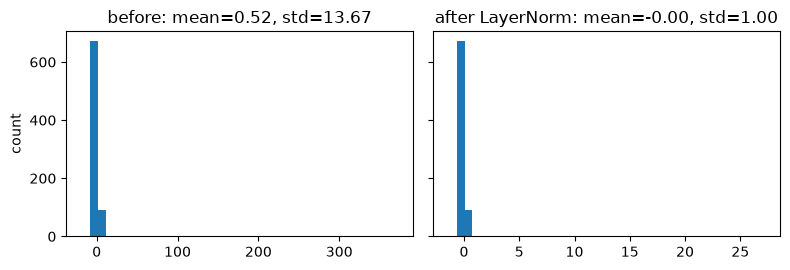

In [16]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(8, 2.8))
for ax, v, title in zip(axes, (x[0], normed_y[0]), ("before", "after LayerNorm")):
    ax.hist(v, bins=40)
    ax.set_title(f"{title}: mean={v.mean():.2f}, std={v.std():.2f}")
axes[0].set_ylabel("count")
plt.tight_layout()
plt.show()

左は LayerNorm の前、右は後の、最初のトークンの 768 個の値の分布です。分布の形はほとんど変わりませんが、横軸の目盛りを見ると、スケールが変わっています。LayerNorm は、値の相対的な大小関係を保ったまま、スケールだけを揃える処理だと分かります。

正規化で全次元を同じスケールにした後、γ/β で必要なスケールの違いを復元します。GPT-2 全体で 25 回使用されます（12 ブロック × 2 + 最終 ln_f × 1）。

## Attention

各トークンが他のトークンとの関係性を計算し、文脈を取り込む処理です。Transformer の原論文のタイトルは "Attention Is All You Need" であり、Attention こそが Transformer の中核です。

原論文では Encoder（双方向に参照）と Decoder（過去のみ参照）の 2 つが導入されましたが、GPT-2 は Decoder のみを使用します（Encoder は説明しません）。Decoder の Attention は **Self-Attention** と呼ばれ、同じシーケンス内のトークン同士の関係を計算します。

Attention の考え方を、検索にたとえた小さな人工的な例で数値にしてみます。関連するトークンを探して情報を集める処理は、3 つの役割に分けられます。

- **Q (Query)**: 「何を探しているか」（検索クエリ）。ここでは軸を [動物, 地名, 動作] とする
- **K (Key)**: 「自分は何を持っているか」（検索インデックス）。Q と同じ軸で表現し、該当する軸だけ 1 にする
- **V (Value)**: 「実際の情報」（検索結果）。ここでは意味のない任意の数値

3 つのトークン `cat`・`Paris`・`run` が、それぞれ K と V を持ちます。Q と K の内積が大きいほど「探しものに合う見出し」なので、その V を多く受け取ります。内積の値（スコア）は、Softmax で合計が 1 になるよう調整して、注目度にします。

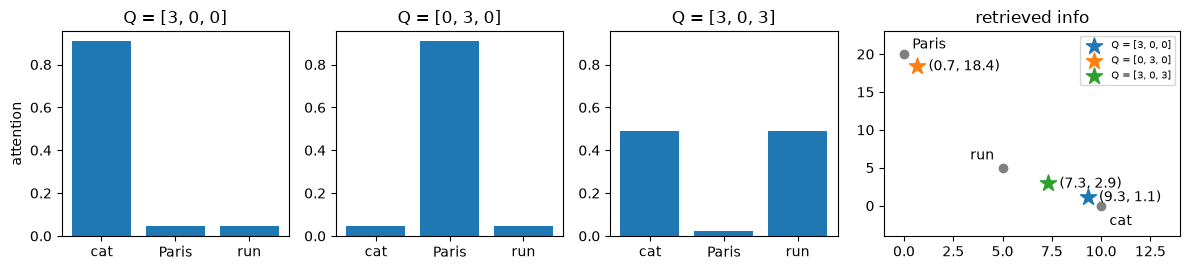

In [17]:
tokens = ["cat", "Paris", "run"]

# K（見出し）: 軸は [動物, 地名, 動作]
K = np.array([[1, 0, 0],   # cat
              [0, 1, 0],   # Paris
              [0, 0, 1]],  # run
             dtype=np.float32)
# V（中身）: 選ばれたときに渡す情報
V = np.array([[10, 0],     # cat
              [0, 20],     # Paris
              [5, 5]],     # run
             dtype=np.float32)

# Q（探しもの）を変えると、取り出される情報が変わる
results = []
for query in [[3, 0, 0], [0, 3, 0], [3, 0, 3]]:
    scores = K @ np.array(query, dtype=np.float32)  # Q と K の内積: 見出しが探しものに合うほど大きい
    weights = softmax(scores)                       # 注目度（合計 1）
    result = weights @ V                            # 注目度で V を混ぜる
    results.append((query, weights, result))

# 左の 3 つ: Q ごとの注目度
fig, axes = plt.subplots(1, 4, figsize=(12, 2.8),
                         gridspec_kw={"width_ratios": [1, 1, 1, 1.3]})
for ax, (query, weights, result) in zip(axes, results):
    ax.bar(tokens, weights)
    ax.set_title(f"Q = {query}")
    ax.sharey(axes[0])
axes[0].set_ylabel("attention")

# 右: 取り出された情報（★）を、V（●）と同じ平面に置く
ax = axes[3]
ax.scatter(V[:, 0], V[:, 1], color="gray")
offsets = {"cat": (6, -14), "Paris": (6, 4), "run": (-6, 6)}  # ラベルの位置（★との重なりを避ける）
for token, v in zip(tokens, V):
    dx, dy = offsets[token]
    ax.annotate(token, v, textcoords="offset points", xytext=(dx, dy), ha="left" if dx > 0 else "right")
for query, weights, result in results:
    ax.scatter(*result, marker="*", s=150, label=f"Q = {query}")
    ax.annotate(f"({result[0]:.1f}, {result[1]:.1f})", result, textcoords="offset points", xytext=(8, -3))
ax.set_xlim(-1, 14)
ax.set_ylim(-4, 23)
ax.set_title("retrieved info")
ax.legend(fontsize=7, loc="upper right")
plt.tight_layout()
plt.show()

グラフの左の 3 つは、探しもの（Q）ごとの注目度です。右は、その注目度で V を混ぜて取り出された情報（★）を、V（●）と同じ平面に置いたものです。Q を変えると、注目度が集まるトークンが入れ替わります。

- **動物を探す（`Q = [3, 0, 0]`）**: Q が `cat` の K と一致するので、`cat` に 0.91 の注目度が集まります。取り出された `(9.3, 1.1)` は、`cat` の V `(10, 0)` の近くに来ます（残りの 0.05 ずつが `Paris` と `run` の V の混入です）。
- **地名を探す（`Q = [0, 3, 0]`）**: 今度は `Paris` に 0.91 が集まり、取り出された `(0.7, 18.4)` は `Paris` の V `(0, 20)` の近くに来ます。
- **動物か動作を探す（`Q = [3, 0, 3]`）**: `cat` と `run` に 0.49 ずつ集まります。取り出された `(7.3, 2.9)` は、`cat` の V `(10, 0)` と `run` の V `(5, 5)` のほぼ中間です。

K と V は変えずに Q だけを変えても、取り出される情報が変わります。注目度が 1 にならないのは、Softmax が合計 1 になるよう調整する際に、スコアの低いトークンにもわずかな重みを残すためです。

この「Q と K の内積で注目度を決め、その注目度で V を混ぜ合わせて取り出す」処理が **Attention** です。

実際のモデルでは、文中のすべてのトークンが自分の Q を持ち、それぞれが他のトークンの K と照合して、V を集めます。これにより、各トークンのベクトルに周囲のトークンの情報（文脈）が取り込まれます。

この例の「動物を探す」「地名を探す」「動物か動作を探す」のように、異なる観点で独立に行う検索の 1 つ 1 つに相当するものを**ヘッド**と呼びます。実際のモデルでは、複数のヘッドが並行して、それぞれ異なる観点で文脈を捉え、最後に結果を結合します。これにより多面的な情報を取り込めます（**Multi-Head Attention**）。

次の節から、この処理を実際のモデルの実装で順に確認します（Q・K・V への変換 → スコア計算 → Softmax → V の重み付き平均）。

### Q, K, V への変換

先ほどの例では Q・K・V を手で与えましたが、実際のモデルでは、各トークンの埋め込みベクトル（768 次元）から**学習済みの行列で変換して作ります**。入力ベクトルをそのまま使うと検索する側とされる側を区別できないため、役割ごとに異なる投影行列を使います。

- 同じ入力ベクトル `x` に、**別々の 3 つの行列** $W_Q$・$W_K$・$W_V$ を掛けて、Q・K・V をそれぞれ作る
- 3 つの行列の重みは別々に学習されるため、同じトークンでも「探しもの」「見出し」「中身」として異なる役割を持つベクトルになる
- 実装上は、3 つの行列を横に連結した 1 つの大きな行列 `w_qkv`（768 → 2304）で一度に計算し、結果を 3 つに分割する（2304 = 768 × 3）

つまり分割されるのは入力ではなく、**変換後の結果**です。

変換後の Q・K・V は、さらに 768 次元を 12 個に等分します（各 64 次元）。この 1 つ分が、先ほど説明した**ヘッド**です。各ヘッドは、自分の 64 次元分の Q・K・V だけを使って、前述の検索（Q で K を照合し、V を集める）を独立に行います。具体的な手順は以降の節で説明し、12 ヘッド分の結果は最後に 1 つに結合します。

`seq_len` を入力のトークン列長とします。

以降のコードでは、動作を追いやすいように、ブロック 0 の Attention だけを取り出して動かします。ブロック 0 の入力は埋め込みそのもので、文脈はまだ取り込まれていません。後ろのブロックには、前のブロックで文脈が取り込まれたものが入力されるため、注目の傾向は層によって異なります。

次のコードは、埋め込み `embedded_x` をブロック 0 の LayerNorm（`ln_1`）に通したものを `x` として、ブロック 0 の Attention に渡し、Q・K・V をまとめて作る部分です。`w_qkv` と `b_qkv` は学習済みの重みとバイアスで、`x @ attn.w_qkv + attn.b_qkv` の 1 回の計算で、各トークンの 768 次元のベクトルが、Q・K・V を連結した 2304 次元のベクトルに変換されます。この段階ではまだ分割していないため、確認として形だけを表示します。

In [18]:
# 入力を設定（ブロック 0 の LayerNorm を通した埋め込み）
x = blocks[0].ln_1(embedded_x)

# ブロック 0 の Attention を取り出す
attn = blocks[0].attn

# 以降の引用コードは Attention クラスの中身
seq_len, embed_dim = x.shape

# (seq_len, 768) → (seq_len, 2304)
qkv = x @ attn.w_qkv + attn.b_qkv

# 確認
print("x（トークン数, 埋め込み次元）:", x.shape)
print("qkv:", qkv.shape, "(トークン数, Q・K・V を連結した次元)")

x（トークン数, 埋め込み次元）: (5, 768)
qkv: (5, 2304) (トークン数, Q・K・V を連結した次元)


`x @ attn.w_qkv` の `@` は**行列積**です。ベクトルどうしの内積そのものではありませんが、実際には、複数の内積を一括で計算するために行列積を使っています。

`x` は形が `(トークン数, 768)` の行列で、1 行が 1 トークンのベクトルです。`w_qkv` は `(768, 2304)` の行列で、1 列が 768 個の重みを持つ 1 本のベクトルです。行列積 `A @ B` は、A の各行と B の各列の内積を、すべての組み合わせについて計算して並べる演算です。ここでの結果（`qkv`）は `(トークン数, 2304)` の行列で、`qkv[i, j]` は、i 番目のトークンのベクトルと、`w_qkv` の j 列目の内積になります。

3 次元のベクトルで、イメージを示します。$a_1 = (1, 2, 3)$、$a_2 = (1, 0, 2)$、$b_1 = (2, 0, 1)$、$b_2 = (1, 1, 1)$ とします。

まず、横ベクトル（1 行の行列）と縦ベクトル（1 列の行列）の行列積は、内積と同じ計算になります。

$$
\begin{pmatrix} 1 & 2 & 3 \end{pmatrix}
\begin{pmatrix} 2 \\ 0 \\ 1 \end{pmatrix}
= 1 \times 2 + 2 \times 0 + 3 \times 1
= 5
$$

つまり、$a_1 \cdot b_1 = 5$ です。ここで縦ベクトルを 2 本並べると、$a_1$ と $b_1$、$a_1$ と $b_2$ の 2 つの内積が、行列積 1 回で求まります。

$$
\begin{pmatrix} 1 & 2 & 3 \end{pmatrix}
\begin{pmatrix} 2 & 1 \\ 0 & 1 \\ 1 & 1 \end{pmatrix}
=
\begin{pmatrix} a_1 \cdot b_1 & a_1 \cdot b_2 \end{pmatrix}
=
\begin{pmatrix} 5 & 6 \end{pmatrix}
$$

さらに横ベクトルも 2 本並べると、$a_1, a_2$ と $b_1, b_2$ のすべての組み合わせ、4 つの内積が求まります。

$$
\begin{pmatrix} 1 & 2 & 3 \\ 1 & 0 & 2 \end{pmatrix}
\begin{pmatrix} 2 & 1 \\ 0 & 1 \\ 1 & 1 \end{pmatrix}
=
\begin{pmatrix}
a_1 \cdot b_1 & a_1 \cdot b_2 \\
a_2 \cdot b_1 & a_2 \cdot b_2
\end{pmatrix}
=
\begin{pmatrix} 5 & 6 \\ 4 & 3 \end{pmatrix}
$$

左の行列が `x`（ここでは 2 トークン分）、右の行列が `w_qkv`（ここでは 2 列）、結果の行列が `qkv` に相当します。トークンが増えれば左の行が増え、列が増えれば右の列が増えて、結果もそれぞれ行と列が増えます。

つまり、ここでは「複数の内積を一括で計算する」ために、行列積を使っています。先ほどの Step 4 の `normed_x @ wte.T` も、以降の `@` も、ベクトルを並べた行列どうしの積として読みます。

In [19]:
# (seq_len, 2304) → (seq_len, 768) × 3 分割
q, k, v = np.split(qkv, 3, axis=-1)
# 各 (seq_len, 768) → (seq_len, 12, 64) → (12, seq_len, 64)
q = q.reshape(seq_len, 12, 64).transpose(1, 0, 2)
k = k.reshape(seq_len, 12, 64).transpose(1, 0, 2)
v = v.reshape(seq_len, 12, 64).transpose(1, 0, 2)
d_k = q.shape[-1] # ヘッド当たりの次元数

# 確認
print("q（ヘッド数, トークン数, ヘッド当たりの次元数）:", q.shape)
print("k（ヘッド数, トークン数, ヘッド当たりの次元数）:", k.shape)
print("v（ヘッド数, トークン数, ヘッド当たりの次元数）:", v.shape)

q（ヘッド数, トークン数, ヘッド当たりの次元数）: (12, 5, 64)
k（ヘッド数, トークン数, ヘッド当たりの次元数）: (12, 5, 64)
v（ヘッド数, トークン数, ヘッド当たりの次元数）: (12, 5, 64)


先ほどの出力のとおり、`qkv` は `(5, 2304)` で、Q・K・V を横に連結した形です。3 つの行列を別々に掛ける代わりに、連結した 1 つの行列 `w_qkv` を掛けて一括で計算し、あとから `np.split` で 3 等分しています。行列積 1 回で済むので、効率が良くなります。結果は同じです。

分割後の `q`・`k`・`v` は、どれも `(12, 5, 64)`（ヘッド数, トークン数, ヘッド当たりの次元数）で、同じ大きさです。同じ大きさになるのには理由があります。

- **Q と K**: 内積でスコアを計算するので、次元数が同じでなければなりません。
- **V**: 重み付き平均で足し合わせるので、トークンごとの V も同じ次元数でそろいます。ここでは K と同じ 64 次元にして、ヘッドの出力（64 次元）を 12 個並べると、元の 768 次元にちょうど戻るようにしています。

このように Q・K・V を同じ大きさにそろえると、全ヘッド・全トークンを 1 つの配列として扱え、まとめて計算できます。

### スコア計算

Q と K の内積で関連度を計算します。内積はベクトルが同じ方向を向いているほど大きくなるため、関連性の高いトークン同士ほどスコアが高くなります。次元数が大きいと内積の値が過大になるため、$\sqrt{d_k}$ でスケーリングします。

In [20]:
scores = q @ k.transpose(0, 2, 1) / math.sqrt(d_k)

# 確認
print(scores.shape)

(12, 5, 5)


> `np.sqrt(d_k)` は `np.float64` のスカラーを返すため、float32 の配列を割ると結果が float64 に格上げされ、以降の計算が遅くなります。そこで Python 標準の `math.sqrt` を使っています（GELU の定数も同様）。

### 因果マスキングと Softmax

GPT-2 では、Q と K による検索の対象は、自分自身と、文中で自分より文頭側にあるトークンだけです。つまり**後方参照**しかできません。`The capital of France is` の 5 トークンなら、各トークンが参照できる範囲は次のようになります（行が注目する側、列が注目される側）。

| 注目する側＼注目される側 | The | capital | of | France | is |
|---|---|---|---|---|---|
| The | ○ | | | | |
| capital | ○ | ○ | | | |
| of | ○ | ○ | ○ | | |
| France | ○ | ○ | ○ | ○ | |
| is | ○ | ○ | ○ | ○ | ○ |

`France` は文頭側の `The capital of` と自分自身は参照できますが、文末側の `is` は参照できません。最後の `is` だけが、5 トークンすべてを参照できます。

表の空白（右上の三角形）は、未来のトークンです。GPT-2 は「次の単語を予測する」モデルで、学習時には各位置で「次のトークン」を同時に予測します。もし `capital` の位置で文末側の `of France is` が見えてしまうと、答えを見て予測することになります。また、推論時には未来のトークンはまだ存在しません。学習時と推論時で条件を揃えるために、スコアの上三角部分を $-10^{10}$ で上書きして隠します。これを**因果マスク**と呼びます。

スコアを確率分布に変換するため **Softmax** を適用します。Softmax は各スコアの指数 $\exp(x)$ を取り、合計で割ることで全体の和が 1 になるよう正規化する関数です。最もスコアが高い要素に高い確率が割り当てられます。マスクされた位置は $-10^{10}$ なので、$\exp(-10^{10}) \approx 0$ となり実質的に無視されます。

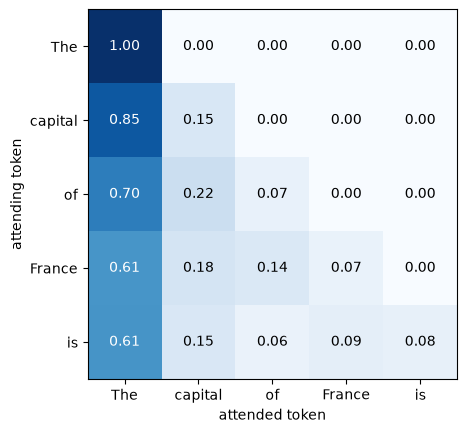

In [21]:
def softmax(x):
    # `exp(x)` は値が大きいとオーバーフローするため、最大値を引いてから計算しています。
    # 最大値を引いても分子・分母に同じ定数がかかるため結果は変わりません。
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

mask = np.tril(np.ones((seq_len, seq_len)))
scores = np.where(mask == 0, -1e10, scores)
probs = softmax(scores)  # 注目度行列

# ヘッド 0 の注目度をヒートマップで見る（行が注目する側、列が注目される側。色が濃いほど高い）
words = [tokenizer.decode([t]).strip() for t in input_ids]
plt.imshow(probs[0], cmap="Blues", vmin=0, vmax=1)
plt.xticks(range(seq_len), words)
plt.yticks(range(seq_len), words)
plt.xlabel("attended token")
plt.ylabel("attending token")
for r in range(seq_len):
    for c in range(seq_len):
        plt.text(c, r, f"{probs[0][r, c]:.2f}", ha="center", va="center",
                 color="white" if probs[0][r, c] > 0.5 else "black")
plt.show()

ヒートマップは、ヘッド 0 の注目度（行が注目する側、列が注目される側）です。

- 右上の三角形（未来のトークン）は、因果マスクによってすべて 0（白）になっています。
- 1 行目の `The` は自分自身しか参照できないので、注目度は 1.00 です。
- 行が下がるほど参照できるトークンが増え、注目度は複数のトークンに分かれます。最後の行の `is` は、5 トークンに分散しています。
- このヘッドでは、どの行も先頭の `The` への注目度が最も高くなっています。

各行の合計は、すべて 1 になっています。Softmax によって、行ごとに合計が 1 の確率分布になっているためです。

先ほどの表を、列方向（注目される側）から読み直してみます。すると、情報は文頭側から文末側への一方向にしか伝わらないことが分かります。`The` の情報は `capital`・`of`・`France`・`is` に、`capital` の情報は `of`・`France`・`is` に流れ込みますが、逆向きには流れません。

その結果、全トークンを参照できる最後の `is` には、それ以前のすべてのトークンの情報が集まります。次の単語の予測に最終トークンの出力だけを使うのは、このためです（後述）。

### Value の重み付き平均

`probs` は、Q と K の内積（スコア）にマスクと Softmax を適用して得た注目度です。つまり、Q と K による検索の結果にあたります。この `probs` を重みとして V の加重平均を取り、文脈を反映したベクトルを得ます。注目度の高いトークンほど、その V が多く流れ込みます。

In [22]:
out = probs @ v

# 確認
print(out.shape)

(12, 5, 64)


### 出力射影

最後に 12 ヘッドの結果を結合して 768 次元に戻し、出力射影を適用します。

In [23]:
merged = out.transpose(1, 0, 2).reshape(seq_len, embed_dim)  # 12 ヘッドを結合
proj = merged @ attn.w_out + attn.b_out                      # 出力射影

# 最後のトークン（is）が、各ヘッドでどのトークンに最も注目しているか
words = [tokenizer.decode([i]).strip() for i in input_ids]
for h in range(12):
    w = probs[h, -1]
    print(f"ヘッド {h:2d}: {words[w.argmax()]:8s} {w.max():.2f}")

print(proj.shape)  # 12 ヘッドを結合して射影: (seq_len, 768)

ヘッド  0: The      0.61
ヘッド  1: is       0.98
ヘッド  2: The      0.47
ヘッド  3: is       0.80
ヘッド  4: is       0.27
ヘッド  5: is       0.92
ヘッド  6: France   0.35
ヘッド  7: is       0.33
ヘッド  8: is       0.47
ヘッド  9: The      0.42
ヘッド 10: The      0.40
ヘッド 11: The      0.47
(5, 768)


出力の各行は、最後のトークン `is` が、そのヘッドで最も注目しているトークンと、その注目度です。`The` に注目するヘッドが 5 つ（0, 2, 9, 10, 11）、`is` 自身に注目するヘッドが 6 つ（1, 3, 4, 5, 7, 8）、`France` に注目するヘッドが 1 つ（6）あります。このようにヘッドごとに注目先が異なり、それぞれ違う観点で情報を集めています。

12 ヘッドの結果は結合され、出力射影で 768 次元に戻されます（出力の形は `(5, 768)`）。

12 行の文字では全体の傾向が見えにくいので、ヘッド（縦）と注目されるトークン（横）のヒートマップにして、`is` の注目先がヘッドごとにどう違うかをまとめて見ます。色が濃いほど注目度が高くなります。

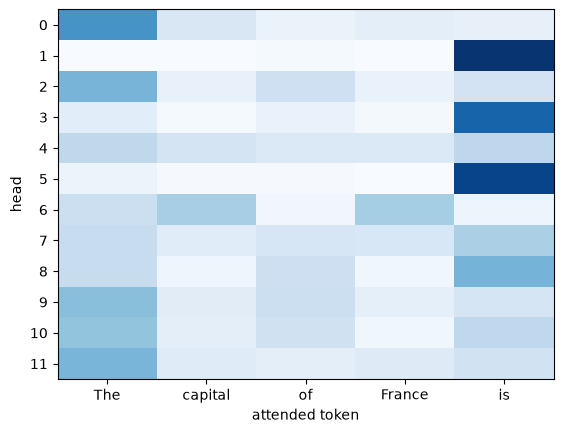

In [24]:
words = [tokenizer.decode([t]).strip() for t in input_ids]
plt.imshow(probs[:, -1], cmap="Blues", vmin=0, vmax=1, aspect="auto")
plt.xticks(range(seq_len), words)
plt.yticks(range(12))
plt.xlabel("attended token")
plt.ylabel("head")
plt.show()

`is` 自身に強く注目するヘッド（1, 3, 5 など）が右端に、`The` に注目するヘッドが左端に濃く出ています。

## 残差接続

Attention の出力は、そのまま次の処理に渡すのではなく、入力に**加算**します。`x = x + f(x)` という形で各処理の出力を元の入力に加算することを**残差接続**と呼びます。層の出力で上書きするのではなく「変更分を加える」構造です。これにより勾配消失を防ぎ、深いモデルでも学習が安定します。

情報の流れとして見ると、`x` は情報の幹線（**残差ストリーム**）であり、Attention や MLP は幹線に情報を「追加」するだけです。初期の Embedding は最終層まで直接伝わります。

GPT-2 は処理の**前**に LayerNorm を置く **Pre-LayerNorm** を採用しています。残差接続のパスがモデル全体を貫通するため、信号が深層まで伝わりやすくなります。

ブロック 0 で、Attention の出力 `proj` を、Attention に入る前の入力 `embedded_x` に加算します。LayerNorm を通したのは Attention に渡した値だけで、加算する側は LayerNorm を通す前の `embedded_x` です。

In [25]:
# Attention の出力を、入力（埋め込み）に加算する（残差接続）
connected_x = embedded_x + proj

# 確認
print("embedded_x:", embedded_x.shape, "+ proj:", proj.shape, "->", connected_x.shape)
print("norm(embedded_x):  ", np.linalg.norm(embedded_x, axis=-1))
print("norm(proj):        ", np.linalg.norm(proj, axis=-1))
print("norm(connected_x): ", np.linalg.norm(connected_x, axis=-1))

embedded_x: (5, 768) + proj: (5, 768) -> (5, 768)
norm(embedded_x):   [10.132026   6.2453856  5.2828484  5.5339622  4.9377227]
norm(proj):         [22.145576 31.166588 27.412516 34.03442  28.357483]
norm(connected_x):  [26.79642  32.713398 28.624733 34.710682 29.221094]


出力の 1 行目は形で、`embedded_x` と `proj` はどちらも `(5, 768)` なので、そのまま加算できます。加算しても形は変わりません。

2 行目以降は、各トークンのベクトルの大きさ（ノルム）です。ここではブロック 0 の一例ですが、`proj`（Attention の出力）の大きさは `embedded_x`（元の埋め込み）より大きく、Attention が幹線に加える変更は小さくないことが分かります。それでも、元の埋め込みは加算によって `connected_x` に残っています。

## MLP

各トークンを**独立に**処理する特徴変換です。Attention が「トークン間の情報伝達」（横方向）なら、MLP は「トークン単体の意味の深掘り」（縦方向）です。Attention は情報を集約しますが、集めた情報を「解釈」する処理は行いません。MLP がその役割を担います。

768 次元のベクトルを一度 4 倍の 3072 次元に拡張し、非線形変換してから元の 768 次元に圧縮します。高次元空間で多くの特徴を同時に表現し、非線形変換で選別するという仕組みです。

MLP への入力は、残差接続で Attention の出力を加算した `connected_x` に、2 つ目の LayerNorm（`ln_2`）を適用した値です。

In [26]:
# 以降の引用コードは MLP クラスの中身なので、self を用意して動かす
self = blocks[0].mlp
x = blocks[0].ln_2(connected_x)  # MLP への入力（残差接続の結果に LayerNorm を適用）

i = x @ self.w_fc + self.b_fc         # 768 → 3072（4倍に拡張）
a = gelu(i)                           # 非線形変換（活性化関数）
out = a @ self.w_proj + self.b_proj   # 3072 → 768（元に圧縮）

# 確認
print(x.shape, "->", i.shape, "->", out.shape)  # 768 → 3072 → 768

words = [tokenizer.decode([t]).strip() for t in input_ids]

# GELU の前後を比較（France の最初の 8 次元）
k = words.index("France")
print("i:", i[k, :8].round(3))
print("a:", a[k, :8].round(3))

# 3072 個の特徴のうち、GELU の後に強く残る（0.1 超）個数
for word, count in zip(words, (gelu(i) > 0.1).sum(axis=-1)):
    print(f"{word:8s} {count}")

(5, 768) -> (5, 3072) -> (5, 768)
i: [ 0.396 -1.109 -1.302 -0.042  0.222 -0.199 -1.112 -0.74 ]
a: [ 0.259 -0.148 -0.126 -0.02   0.131 -0.084 -0.148 -0.17 ]
The      133
capital  271
of       181
France   444
is       183


出力の 1 行目は、次元の流れ（768 → 3072 → 768）です。MLP は一度 4 倍に広げてから、元の次元に戻します。

2 行目と 3 行目は、`France` の最初の 8 次元を、GELU の前（`i`）と後（`a`）で比べたものです。正の値は少し小さくなり（`0.396 → 0.259`、`0.222 → 0.131`）、負の値は 0 に近づきます（`-1.302 → -0.126`、`-1.109 → -0.148`）。

最後の数値は、3072 個の特徴のうち、GELU の後に 0.1 を超えて残った個数です。`The` は 133 個、`France` は 444 個で、どのトークンでも全体の数 % から 15 % ほどしか残りません。残りの大半は GELU で抑制され、トークンごとに違う一部の特徴だけが選ばれています。内容語の `capital` と `France` は、`The` や `of`、`is` より多く残っています。ここではブロック 0 の一例で、0.1 という閾値も目安です。

### GELU

GELU は ReLU を滑らかにした活性化関数で、正の値はほぼそのまま通過し、負の値は大きく抑制されます。非線形変換がないと、どれだけ層を重ねても全体が単なる線形変換に潰れてしまうため、非線形性の導入が不可欠です。

In [27]:
samples = np.array([-3, -1, 0, 1, 3], dtype=np.float32)
print(samples, "->", gelu(samples))

[-3. -1.  0.  1.  3.] -> [-0.00363734 -0.158808    0.          0.841192    2.9963627 ]


入力の正の値は `1 → 0.84`、`3 → 3.00` とほぼそのまま通り、負の値は `-1 → -0.16`、`-3 → -0.004` と 0 に近づきます。0 の入力は 0 のままです。

入力を連続的に変えて GELU の出力を描くと、次のようになります。破線は、入力をそのまま出力する直線 `y = x` です。

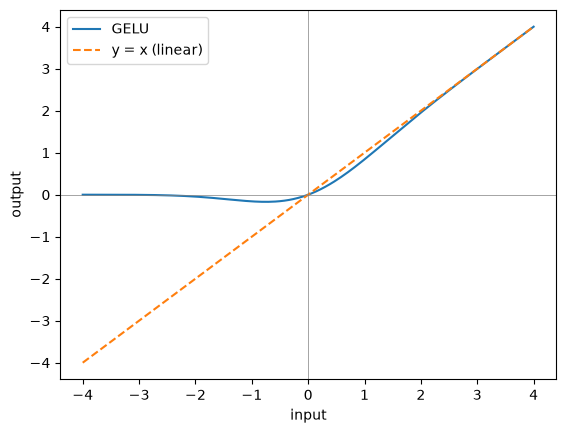

In [28]:
xs = np.linspace(-4, 4, 200).astype(np.float32)
plt.plot(xs, gelu(xs), label="GELU")
plt.plot(xs, xs, "--", label="y = x (linear)")
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)
plt.xlabel("input")
plt.ylabel("output")
plt.legend()
plt.show()

正の側では直線 `y = x` にほぼ重なります。負の側では 0 に向かって曲がり、`-1` 付近でわずかに負の値を取ったあと、0 に近づきます。0 付近ではなめらかに折れ曲がっています。このように直線ではない（非線形）ことが、層を重ねても全体が 1 つの線形変換に潰れない理由です。

### MLP の残差接続

MLP の出力も、Attention と同じく残差接続で幹線に加算します。加算する相手は、LayerNorm を通した `x` ではなく、通す前の `connected_x`（Attention の残差接続の結果）です。これでブロック 0 の処理が完結します。

In [29]:
# MLP の出力を、LayerNorm を通す前の connected_x に加算する（残差接続）
block_out = connected_x + out

# 確認
print("norm(connected_x):", np.linalg.norm(connected_x, axis=-1))
print("norm(out):        ", np.linalg.norm(out, axis=-1))
print("norm(block_out):  ", np.linalg.norm(block_out, axis=-1))
print("ブロック 0 の出力と一致:", np.allclose(block_out, blocks[0](embedded_x), atol=1e-4))

norm(connected_x): [26.79642  32.713398 28.624733 34.710682 29.221094]
norm(out):         [124.380875  30.390959  30.005434  35.954567  32.879833]
norm(block_out):   [132.81807   54.512966  53.544956  62.96802   56.50396 ]
ブロック 0 の出力と一致: True


出力の 1 行目から 3 行目は、`connected_x`、MLP の出力 `out`、加算後の `block_out` の、各トークンのベクトルの大きさ（ノルム）です。MLP の出力も `connected_x` と同程度か、それ以上の大きさがあり、特に最初のトークン `The` では `out` が大きくなっています。それでも、加算なので `connected_x` の内容は `block_out` に残っています。

最後の行は、この `block_out` が、`blocks[0](embedded_x)`（TransformerBlock をそのまま実行した結果）と一致していることの確認です。ここまでで、ブロック 0 の「LayerNorm → Attention → 残差接続 → LayerNorm → MLP → 残差接続」が、順に確認できました。この出力が、ブロック 1 の入力になります。

## 文脈付き埋め込み

12 ブロックを通過すると、同じ単語でも文脈によって異なるベクトルに変化します。これを**文脈付き埋め込み** (Contextual Embedding) と呼びます。例えば "river bank" と "money bank" の "bank" は、Embedding 層では同一ですが、Attention によって周囲の単語の情報を取り込み、異なるベクトルへと分岐していきます。

因果マスクにより、各トークンは自分自身と過去のトークンだけを参照できるため、最後のトークンにはそれより前のすべてのトークンの情報が集約されます。

そのため、理論上は最後のトークンのベクトルを文全体の埋め込み（文埋め込み）として扱えます。ただし、GPT-2 のように「次のトークンを予測する」ことに特化して学習されたモデルのベクトルは、次の予測に必要な情報を表すように作られています。文の意味が近いほどベクトルも近くなるように学習された、埋め込みに特化したモデルとは、特性が異なります。

# 出力とサンプリング

12 層の Transformer Block と最終 LayerNorm を通過したベクトルから、次の単語の確率分布を生成します。

## LM Head（Weight Tying）

通常、出力層には独立した重み行列を用意しますが、GPT-2 では入力の Embedding 行列（WTE）をそのまま出力層にも再利用します。この手法を **Weight Tying** と呼びます。「単語 A を表すベクトル」と「次の単語として A を予測するベクトル」は同じ意味空間にあるべきという考えに基づいており、GPT-2 の 124M パラメーターのうち約 30% を占める行列を共有することでメモリも節約できます。

In [30]:
logits = normed_x @ wte.T  # (seq_len, 768) @ (768, 50257) → (seq_len, 50257)

# 最後のトークンの上位 5 候補
for t in np.argsort(logits[-1])[::-1][:5]:
    print(repr(tokenizer.decode([int(t)])), logits[-1, t])

' the' -100.2498
' now' -100.81753
' a' -100.8555
' France' -101.21015
' Paris' -101.2143


行列積によって各トークンのベクトルと全語彙の埋め込みベクトルとの内積を一括計算しています。内積はベクトルが同じ方向を向いているほど大きくなるため、モデルの最終出力に近い埋め込みを持つトークンほど高いスコアになります。この出力は確率分布の前段階となるスコアで、**ロジット**と呼ばれます。

## サンプリング手法

因果マスクにより最後のトークンにはそれ以前のすべてのトークンの情報が集約されているため、次の単語の予測には最終トークンのロジットだけを使用します。

最終トークンのロジットを Softmax で確率分布に変換した後、次のトークンを選びます。確率分布からどのようにトークンを選ぶかによって、生成されるテキストの性質が変わります。

- **貪欲法**: 最も確率が高いトークンを選択。決定論的だがループが発生しやすい
- **Temperature**: ロジットを温度 T で割ってから Softmax を適用し、分布の尖り具合を調整。低温（T < 1）で保守的、高温（T > 1）で多様な生成になる
- **Top-k**: 上位 k 個のトークン以外をマスクし、候補数を固定
- **Top-p（Nucleus）**: 累積確率が p に達するまでのトークンを候補にする。語彙の分布に応じて候補数が動的に変わるため、Top-k より適応的

Temperature による分布の違いを、最後のトークンのロジットで確認します。確率の上位 10 トークンについて、温度 T を変えたときの確率を比べます。

T = 0.5: 上位 10 件の確率の合計 0.91
T = 1: 上位 10 件の確率の合計 0.36
T = 2: 上位 10 件の確率の合計 0.03


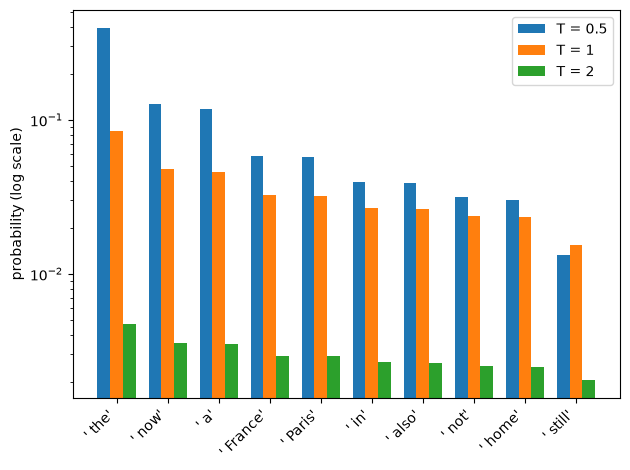

In [31]:
top = np.argsort(logits[-1])[::-1][:10]
labels = [repr(tokenizer.decode([int(t)])) for t in top]
width = 0.25
for j, T in enumerate([0.5, 1, 2]):
    p = softmax(logits[-1] / T)
    print(f"T = {T}: 上位 10 件の確率の合計 {p[top].sum():.2f}")
    plt.bar(np.arange(10) + (j - 1) * width, p[top], width, label=f"T = {T}")

# 上位 10 件の確率を温度付きソフトマックスで可視化
plt.xticks(range(10), labels, rotation=45, ha="right")
plt.yscale("log")
plt.ylabel("probability (log scale)")
plt.legend()
plt.tight_layout()
plt.show()

T = 1 が元の分布です。T を 0.5 に下げると、最も確率が高い `' the'` が約 0.40 まで集中し、分布が尖ります。上位 10 件の確率の合計も、0.36 から 0.91 に増えます。逆に T を 2 に上げると、上位のトークンでも確率が 0.005 以下まで下がり、上位 10 件の合計は 0.03 です。確率が語彙全体に広がっていることを表します（縦軸は対数です）。温度が低いほど決定的に、高いほど多様な生成になります。

## 自己回帰生成

GPT-2 は一度に 1 トークンずつ予測します。予測したトークンを入力に追加して再び推論するループを繰り返すことで文章を生成します。

In [32]:
input_ids = tokenizer.encode(text)
n_tokens_to_generate = 8

print(text, end="")
for _ in range(n_tokens_to_generate):
    logits = model(np.array(input_ids))
    next_token = int(np.argmax(logits[-1, :]))
    input_ids.append(next_token)
    print(tokenizer.decode([next_token]), end="", flush=True)  # 生成したトークンから順に表示

The capital of France is the capital of the French Republic, and

毎回入力全体をモデルに通し、最後のトークンの確率分布から次のトークンを選びます。なお、この素朴な実装では毎回全トークンを再計算しています。次のセクションで説明する KV キャッシュを使えば、新しいトークンの計算だけで済むようになります。

# KV キャッシュ

自己回帰生成では毎回全トークンを再計算しますが、Transformer Block の中で他のトークンを参照するのは Attention だけです。MLP・LayerNorm・Embedding・LM Head はすべてトークン単位の独立した処理です。さらに因果マスクにより過去のトークンの K, V は変わりません。そこで計算済みの K と V を保存しておき、新しいトークンの計算だけで済ませるのが **KV キャッシュ**です。

- **Prefill**: 全プロンプトを処理して K, V をキャッシュに保存
- **Incremental**: 新トークンのみ処理し、K, V をキャッシュに追加。新しいトークンの Q とキャッシュ全体の K でスコアを計算

Attention の計算量は Q の長さ × K の長さに比例します。プロンプト 4 トークンから 3 トークンを生成する場合の計算量を比較すると：

```text
キャッシュなし（毎回全トークンを処理）:
  4×4 + 5×5 + 6×6 + 7×7 = 126

キャッシュあり（Prefill + 新トークンのみ処理）:
  4×4 + 1×5 + 1×6 + 1×7 =  34
```

シーケンスが長くなるほど差は広がります。

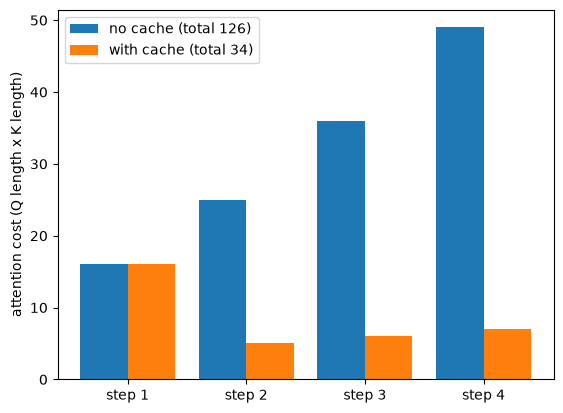

In [33]:
lengths = [4, 5, 6, 7]  # 各ステップの入力トークン数
no_cache = [n * n for n in lengths]
with_cache = [lengths[0] ** 2] + [1 * n for n in lengths[1:]]  # 2 回目以降は新トークン 1 つ

# 各ステップの attention コストを比較するグラフ
steps = np.arange(len(lengths))
plt.bar(steps - 0.2, no_cache, 0.4, label=f"no cache (total {sum(no_cache)})")
plt.bar(steps + 0.2, with_cache, 0.4, label=f"with cache (total {sum(with_cache)})")
plt.xticks(steps, [f"step {i + 1}" for i in steps])
plt.ylabel("attention cost (Q length x K length)")
plt.legend()
plt.show()

キャッシュなしでは毎回全トークンを処理するので、ステップが進むほど計算量が増えます（16 → 25 → 36 → 49、合計 126）。キャッシュありでは、最初のステップ（Prefill）だけが全トークン分で、以降は新しいトークン 1 つ分だけなので、5 → 6 → 7 と緩やかに増えます（合計 34）。

In [34]:
# 確認: KV キャッシュありでも結果は同じ。2 回目以降は新しいトークンだけを処理する
cached_ids = tokenizer.encode(text)
kv_cache = None  # Prefill 前は None
inputs = np.array(cached_ids)
for _ in range(n_tokens_to_generate):
    logits, kv_cache = model(inputs, kv_cache=kv_cache)
    next_token = int(np.argmax(logits[-1, :]))
    cached_ids.append(next_token)
    inputs = np.array([next_token])  # 新トークンのみ
print(cached_ids == input_ids)  # キャッシュなしの結果と一致

True


# まとめ

ここまでの内容を、最初に掲載したコアコードから途中経過の出力を除いて、1 つにまとめます。自己回帰生成のループの中に Step 1〜5 を入れた形で、これだけで文章を生成できます。

In [35]:
text = "The capital of France is"
n_tokens_to_generate = 8

# Step 0: トークナイザー — テキストをトークンIDの列に変換
input_ids = tokenizer.encode(text)
print(text, end="")

for _ in range(n_tokens_to_generate):
    # Step 1: Embedding — トークンIDをベクトルに変換し、位置情報を加算
    x = wte[input_ids] + wpe[np.arange(len(input_ids))]

    # Step 2: Transformer Block × 12 — 文脈理解と特徴変換を繰り返す
    for block in blocks:
        y = block.ln_1(x)  # 正規化
        y = block.attn(y)  # 文脈理解
        x = x + y          # 残差接続（加算）
        z = block.ln_2(x)  # 正規化
        z = block.mlp(z)   # 特徴変換
        x = x + z          # 残差接続（加算）

    # Step 3: 最終 LayerNorm — 出力前の正規化
    x = ln_f(x)

    # Step 4: LM Head — 全語彙の埋め込みベクトルとの内積（ロジット）を一括計算
    logits = x @ wte.T

    # Step 5: サンプリング — 最後のトークンのロジットから次のトークンを選択
    probs = softmax(logits[-1])
    next_id = np.random.choice(len(probs), p=probs)

    # 選んだトークンを入力に追加して繰り返す（自己回帰生成）
    input_ids.append(int(next_id))
    print(tokenizer.decode([int(next_id)]), end="", flush=True)  # 生成したトークンから順に表示

The capital of France is Auch. Its inhabitants are called Byz

各ステップの役割は、次のとおりです。

- **Step 0〜1**: テキストをトークン ID に変換し、埋め込みベクトルに位置情報を加えて、行列（トークン数, 768）にする
- **Step 2**: Attention でトークン間の文脈を取り込み、MLP で各トークンの特徴を変換する。これを残差接続で積み重ねる
- **Step 3〜4**: 最終 LayerNorm で整えたベクトルと全語彙の埋め込みベクトルとの内積（ロジット）を、行列積で一括計算する
- **Step 5**: 最後のトークンのロジットを Softmax で確率にして、次のトークンを 1 つ選ぶ

これを繰り返すだけで文章が生成されます。KV キャッシュは、このループの中で毎回やり直している計算を省く工夫です。

# GPT-2 から現代の LLM へ

GPT-2 のアーキテクチャは現代の LLM の基本形です。本質的な違いはパラメータ数と学習データの規模であり、基本構造は驚くほど変わっていません。

| | GPT-2 | 現代の LLM |
|---|---|---|
| パラメータ数 | 124M | 数十B〜数百B |
| 層数 | 12 | 数十〜百以上 |
| コンテキスト長 | 1024 | 100K〜2M |
| 位置埋め込み | 学習済み絶対位置 | RoPE 等の相対位置 |
| 正規化 | LayerNorm | RMSNorm |
| 活性化関数 | GELU | SwiGLU |
| Attention | 標準 MHA | GQA / MLA |

表に出てきた用語を簡単に説明します。

| 用語 | 正式名称 | 概要 |
|---|---|---|
| RoPE | Rotary Position Embedding | 位置情報を、埋め込みに足す代わりに、Q と K のベクトルを位置に応じた角度だけ回転させて与える。回転後の内積が相対的な位置関係に依存するため、長い文脈に拡張しやすい |
| RMSNorm | Root Mean Square Normalization | LayerNorm から平均を引く処理とバイアス β を省き、二乗平均平方根（RMS）で割ってスケール γ を掛けるだけにした正規化。計算が軽い |
| SwiGLU | Swish-Gated Linear Unit | MLP の活性化の一種。入力を 2 つに射影し、一方に Swish（SiLU）関数を適用してゲートとし、もう一方と要素ごとに掛ける。GELU の MLP より性能が良いとされる |
| GQA | Grouped-Query Attention | 標準の MHA（Multi-Head Attention）では全ヘッドが独自の K, V を持つが、GQA では複数の Q ヘッドで 1 組の K, V を共有する。KV キャッシュが小さくなる |
| MLA | Multi-head Latent Attention | K, V を低次元の潜在ベクトルに圧縮して保存し、使うときに復元する。GQA よりもさらに KV キャッシュを小さくできる（DeepSeek で採用） |

構造の違いは効率やスケーラビリティの改善であり、「残差ストリーム上で Attention と MLP を繰り返す」という根本的な設計は共通しています。GPT-2 で理解した原理は、そのまま現代の LLM にも応用できます。